# **13장. 문장 생성 모델**  

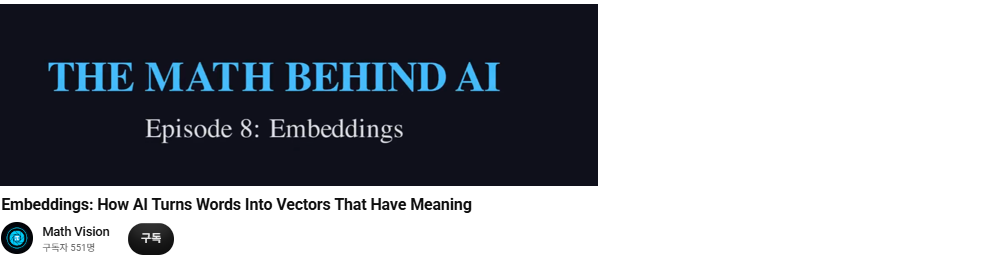

https://www.youtube.com/watch?v=EadwhM6O6oI


이 영상은 문장 시퀀스 모델의 핵심인 **임베딩** 기법을 쉽게 설명하고 있습니다.  
* 문자형 토큰을 슷자 벡터로 바꾸어 의미적 유사성을 학습하는 방법입니다.


---




In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import numpy as np; import matplotlib.pyplot as plt
import tensorflow as tf
import random; import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Flatten, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, EarlyStopping

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 33.1 MB/s eta 0:00:00


[실습 13-01]

In [ ]:
# 말뭉치 파일 지정
file="AI소설.txt"

# 텍스트 파일 불러오기
with open(file, encoding="cp949") as f:
  text=f.read()

# 데이터 전처리
text=text.replace("\n", " ")
text=re.sub(r"([?.!,])", r" \1 ", text)
text

'낡은 라디오의 볼륨 다이얼을 돌릴 때마다 치직거리는 잡음 사이로 먼지 쌓인 주파수들이 비명을 질렀다 .  열일곱 살의 여름은 유난히 길었고 ,  실내 체육관의 코트 바닥처럼 후끈거리는 열기로 가득 차 있었다 .  민우는 외할아버지가 남긴 유품인 구식 라디오를 분해했다 조립하기를 반복하며 그 지루한 시간을 견디고 있었다 .  송신기가 고장 난 라디오는 소리 없이 침묵하고 있었고 ,  소년도 침묵하는 법을 익혀가는 중이었다 .  그날도 옥탑방의 창문 너머로 붉은 노을이 번져나가던 저녁이었다 .  민우가 조심스럽게 다이얼을 맞추던 순간 ,  기적처럼 잡음이 걷히고 맑은 목소리가 흘러나왔다 .  "안녕 ,  거기 누구 있나요 ?  제 목소리가 들리나요 ? " 그것은 마치 아주 먼 곳에서 날아온 전파가 옥탑방에만 내려앉은 것 같은 ,  믿기지 않는 순간이었다 .  목소리의 주인은 자신을 서연이라고 소개했고 ,  민우는 홀린 듯 마이크를 잡고 대답했다 .  "네 ,  들려요 .  아주 잘 들려요 . " 두 사람의 비밀스러운 주파수는 매일 밤 같은 시각에 맞춰졌다 .  서연은 창밖으로 보이는 노을의 색깔을 물었고 ,  민우는 눈앞에 펼쳐진 풍경을 시처럼 묘사해주었다 .  서연은 민우에게 한 번도 가보지 못한 바다의 파도 소리를 들려주었고 ,  민우는 그 소리를 들으며 침대 위에서 파도를 타는 상상을 했다 .  그들은 서로의 얼굴도 ,  사는 곳도 몰랐지만 ,  주파수라는 투명한 실로 연결된 채 서로의 깊은 속마음을 나누었다 .  어느덧 여름이 끝나가고 소나기가 퍼붓던 밤 ,  서연의 목소리가 유난히 가늘게 떨렸다 .  "민우야 ,  만약 이 신호가 끊겨도 우리 다시 만날 수 있을까 ? " 민우는 가슴 한구석이 아릿해지는 것을 느끼며 꼭 다시 만나자고 ,  내가 너를 찾아내겠다고 약속했다 .  하지만 그 약속을 비웃듯 거대한 천둥소리와 함께 전구의 불빛이 깜빡거렸다 .  치직 ,  거리는 귀를 찢는 듯한 소음이 다시 시작되었고 ,  소녀는 거짓말처럼 사라졌다 .  해안가 

[실습 13-02]

In [ ]:
tokenizer = Tokenizer(filters='') # 토크나이저 정의
tokenizer.fit_on_texts([text])  # 토크나이저 최적화

text_encoded = tokenizer.texts_to_sequences([text])[0] # 라벨인코딩

print("라벨 인코딩된 토큰")
print(text_encoded)

라벨 인코딩된 토큰
[22, 158, 159, 124, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 1, 170, 23, 171, 7, 172, 2, 173, 174, 175, 176, 177, 178, 125, 179, 15, 1, 10, 180, 181, 182, 183, 184, 185, 186, 24, 6, 25, 187, 26, 15, 1, 188, 189, 190, 191, 192, 193, 27, 28, 2, 194, 29, 30, 31, 32, 1, 195, 196, 197, 11, 198, 199, 33, 200, 1, 201, 34, 124, 202, 35, 2, 36, 203, 204, 205, 37, 206, 1, 207, 2, 208, 209, 38, 3, 39, 37, 126, 3, 4, 40, 41, 8, 42, 210, 43, 211, 212, 44, 45, 16, 2, 46, 47, 48, 1, 213, 49, 50, 214, 51, 2, 10, 52, 53, 215, 54, 216, 1, 55, 2, 17, 1, 8, 56, 17, 1, 4, 57, 58, 59, 217, 12, 18, 16, 60, 61, 1, 127, 128, 62, 218, 63, 64, 2, 10, 65, 66, 219, 67, 68, 1, 127, 220, 69, 129, 70, 13, 221, 130, 19, 71, 2, 10, 6, 19, 131, 72, 73, 222, 223, 74, 75, 1, 76, 9, 77, 2, 78, 79, 80, 2, 224, 81, 82, 83, 14, 9, 84, 85, 86, 1, 87, 225, 88, 226, 89, 18, 2, 227, 37, 7, 90, 91, 1, 228, 2, 92, 93, 94, 132, 95, 5, 96, 97, 98, 3, 4, 10, 99, 100, 101, 102, 103, 104, 5, 105, 2, 106, 107, 108, 10

[실습 13-03]

In [ ]:
print("인코딩 딕셔너리")
print(tokenizer.word_index); print()
print("토큰 '유난히'의 인덱스:", tokenizer.word_index['유난히']); print()
index_word={v: k for k, v in tokenizer.word_index.items()}
print("디코딩 딕셔너리")
print(index_word); print()
print("7번 인덱스의 토큰:", index_word.get(7)); print()

vocab_size = len(tokenizer.word_index) + 1
print(f"고유 토큰의 수: {vocab_size}")

인코딩 딕셔너리
{'.': 1, ',': 2, '?': 3, '"': 4, '다시': 5, '그': 6, '유난히': 7, '아주': 8, '서로의': 9, '민우는': 10, '너머로': 11, '매일': 12, '못한': 13, '채': 14, '있었다': 15, '같은': 16, '들려요': 17, '밤': 18, '소리를': 19, '수호는': 20, '진우는': 21, '낡은': 22, '살의': 23, '반복하며': 24, '지루한': 25, '견디고': 26, '침묵하고': 27, '있었고': 28, '침묵하는': 29, '법을': 30, '익혀가는': 31, '중이었다': 32, '번져나가던': 33, '조심스럽게': 34, '순간': 35, '기적처럼': 36, '목소리가': 37, '있나요': 38, '제': 39, '그것은': 40, '마치': 41, '먼': 42, '날아온': 43, '내려앉은': 44, '것': 45, '믿기지': 46, '않는': 47, '순간이었다': 48, '주인은': 49, '자신을': 50, '소개했고': 51, '홀린': 52, '듯': 53, '잡고': 54, '"네': 55, '잘': 56, '두': 57, '사람의': 58, '비밀스러운': 59, '시각에': 60, '맞춰졌다': 61, '보이는': 62, '색깔을': 63, '물었고': 64, '눈앞에': 65, '펼쳐진': 66, '시처럼': 67, '묘사해주었다': 68, '한': 69, '가보지': 70, '들려주었고': 71, '침대': 72, '위에서': 73, '상상을': 74, '했다': 75, '그들은': 76, '얼굴도': 77, '사는': 78, '곳도': 79, '몰랐지만': 80, '투명한': 81, '실로': 82, '연결된': 83, '깊은': 84, '속마음을': 85, '나누었다': 86, '어느덧': 87, '끝나가고': 88, '퍼붓던': 89, '가늘게': 90, '떨렸다': 91, '만약': 92, '이': 93, 

[실습 13-04]

In [ ]:
seq_length=10  # 시퀀스 길이

X, y = [], []
for i in range(len(text_encoded) - seq_length):
    X.append(text_encoded[i : i + seq_length])
    y.append(text_encoded[i + 1 : i + 1+ seq_length])

X = np.array(X); y = np.array(y)
print("피처 shape=", X.shape); print(X); print()
print("타깃 shape=", y.shape); print(y)

피처 shape= (790, 10)
[[ 22 158 159 ... 163 164 165]
 [158 159 124 ... 164 165 166]
 [159 124 160 ... 165 166 167]
 ...
 [118 119 120 ... 376 377 155]
 [119 120 133 ... 377 155 122]
 [120 133   5 ... 155 122 123]]

타깃 shape= (790, 10)
[[158 159 124 ... 164 165 166]
 [159 124 160 ... 165 166 167]
 [124 160 161 ... 166 167 168]
 ...
 [119 120 133 ... 377 155 122]
 [120 133   5 ... 155 122 123]
 [133   5 121 ... 122 123   1]]


**큰 말뭉치라면 아래처럼 데이터를 분할하여 학습을 할 수 있습니다.**

이것이 LLM의 표준적인 방법입니다.

In [ ]:
split=int(len(X)*0.8)  # 분할 시점 설정
print("분할 시점 =", split)
x_train=X[:split]; x_test=X[split:]
y_train=y[:split]; y_test=y[split:]
print("훈련용 입력 데이터 차원:", x_train.shape); print("훈련용 타깃 데이터 차원:", y_train.shape); print()
print("검증용 입력 데이터 차원:", x_test.shape); print("검증용 타깃 데이터 차원:", y_test.shape)

분할 시점 = 632
훈련용 입력 데이터 차원: (632, 10)
훈련용 타깃 데이터 차원: (632, 10)

검증용 입력 데이터 차원: (158, 10)
검증용 타깃 데이터 차원: (158, 10)


**하지만 작은 말뭉치에서는 앞뒤 부분의 토큰 분포가 매우 달라서, 이러한 분할 검증 방법이 잘 작동하지 않습니다**.

따라서 이 실습에서는 **전체 데이터**를 사용하여 학습하되, 과대적합을 막기 위해 **에포크 수를 조절**하는 방법을 사용합니다.  



---
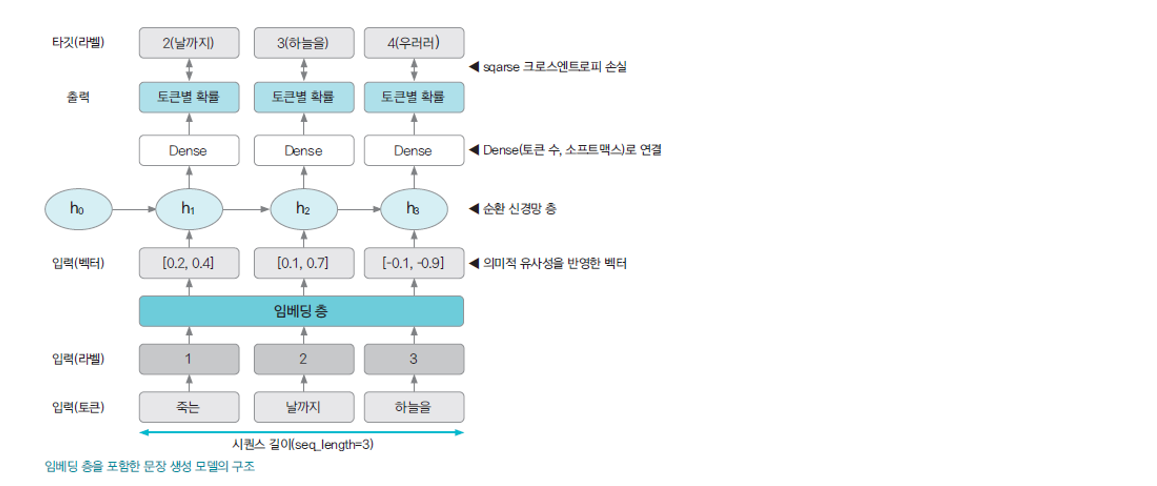


[실습 13-05] & [실습 13-06]

In [ ]:
# 랜덤 시드 고정
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# 임베딩 차원
embedding_dim=32

# 모델 설정
model=Sequential([
    Input(shape=X[0].shape),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),

    GRU(64, return_sequences=True),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(vocab_size, activation='softmax') ])

# 컴파일
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam", metrics=['accuracy'])

# 학습 (전체 데이터 사용)
history=model.fit(X, y, epochs=20)  # 에포크 수 조절(최종 accuracy를 0.5~0.7 정도로 권장)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.0672 - loss: 5.9143
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0818 - loss: 5.7041
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0932 - loss: 5.4449
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1044 - loss: 5.1218
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1225 - loss: 4.7162
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1487 - loss: 4.2243
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2166 - loss: 3.6354
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3090 - loss: 3.0917
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4106 - loss: 2.5773
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4870 - loss: 2.1800
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5601 - loss: 1.8259
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6148 - l

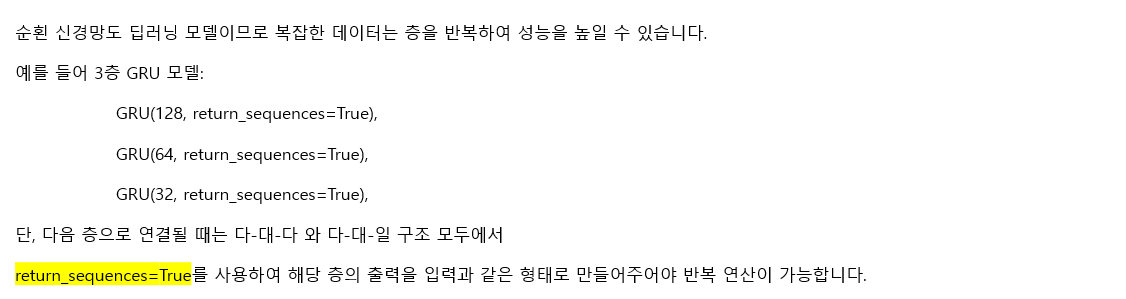

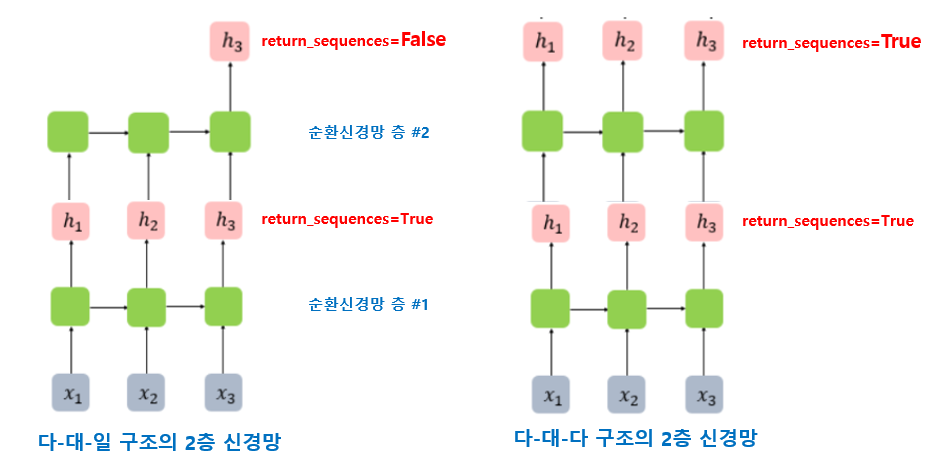

---

### **소프트맥스의 Temperature를 활용한 다양성 조절 방법**

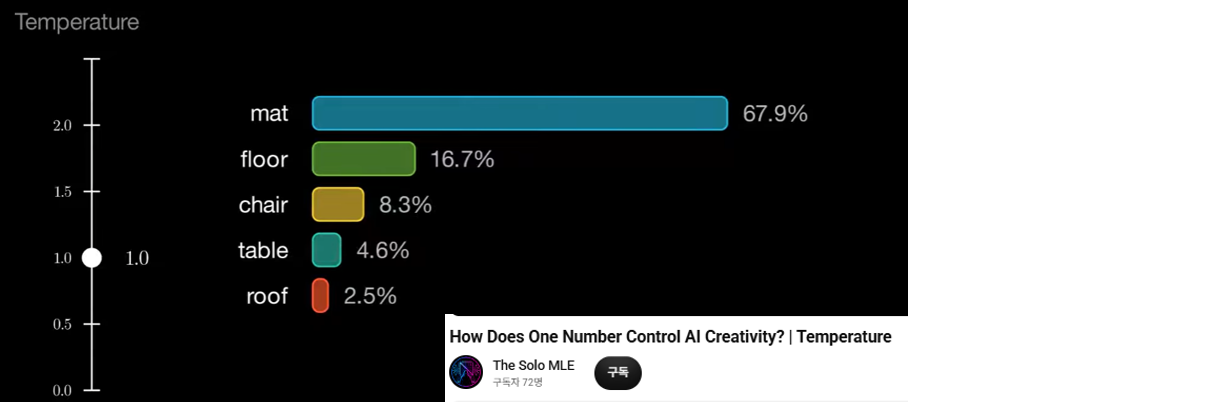

https://www.youtube.com/watch?v=wf1wOtW1Szw

이 동영상은 문장 생성의 다양성을 조절하는 Temperature 사용법을 예를 통해 쉽게 설명합니다. 꼭 시청해 봅시다.

### 샘플링 기법의 문장 생성 함수

In [ ]:
def generate(seed_text, length, temperature=1.0):
    generated_tokens = []

    for _ in range(length):
        # 1. 시드 텍스트 토큰화 및 시퀀스 길이 맞추기
        curr_tokens = tokenizer.texts_to_sequences([seed_text])[0]
        if len(curr_tokens) > seq_length:
            curr_tokens = curr_tokens[-seq_length:]
        pad_tokens = pad_sequences([curr_tokens], maxlen=seq_length, padding='pre')

        # 2. 모델에 입력하여 확률 예측
        probs_all = model.predict(pad_tokens, verbose=0)  # 모든 타임 스텝
        probs = probs_all[0, -1, :]                       # 마지막 타임 스텝의 확률만 추출

        # 3. 반복 패널티 적용 (최근 생성된 20개 토큰의 확률을 2배 축소)
        # 팁: 나눗셈 비율(1.5~2.0)을 직접 조절하여 페널티 강도를 조절할 수 있습니다.
        for token in set(generated_tokens[-20:]):
            probs[token] /= 2

        # 4. Temperature를 적용하여 확률 분포의 뾰족함을 조절
        p_temp = np.log(probs + 1e-10) / temperature
        next_probs = np.exp(p_temp)
        next_probs = next_probs / np.sum(next_probs)

        # 5. 샘플링 및 시드 텍스트 업데이트
        next_index = np.random.choice(len(next_probs), p=next_probs)
        generated_tokens.append(next_index)
        word = index_word.get(next_index)

        # 특수 토큰이나 존재하지 않는 단어를 만나면 종료
        if not word or word == '<pad>':
            break

        seed_text = seed_text + " " + word  # 시드 업데이트

    return seed_text

### 생성 결과

[실습 13-07]

In [ ]:
import textwrap
SEED= "낡은 라디오의 볼륨 다이얼을 돌릴 때마다"
output = generate(seed_text=SEED, length=200, temperature=0.7)
print(textwrap.fill(output, width=60))  # 출력 넓이 조절

낡은 라디오의 볼륨 다이얼을 돌릴 때마다 치직거리는 잡음 사이로 먼지 쌓인 주파수들이 비명을 질렀다 .
열일곱 살의 봄은 유난히 길었고 , 광장 너머로 불어오는 흙먼지는 거친 모래알처럼 폐부 깊숙이 파고들었다 .
수호는 바닷바람이 실어온 유리병을 수집하고 닦아내기를 반복하며 그 지루한 시간을 견디고 있었다 . 하윤은
창밖으로 보이는 노을의 색깔을 물었고 , 소년은 홀린 듯 펜을 잡고 답장을 적었다 . "네 , 들려요 .
아주 잘 들려요 . " 두 사람의 비밀스러운 신호는 매일 오후 정체 모를 유리병들이 밀려와 모래사장에 박혔다
. 진우가 조심스럽게 태엽을 조이던 순간 , 기적처럼 잡음이 걷히고 맑은 목소리가 흘러나왔다 . "안녕 ,
거기 누구 있나요 ? " 그것은 마치 아주 먼 곳에서 날아온 전파가 옥탑방에만 내려앉은 것 같은 , 믿기지
않는 순간이었다 . 편지의 주인은 자신을 다인이라고 소개했고 , 소년은 홀린 듯 마이크를 잡고 대답했다 .
"네 , 들려요 . 아주 잘 들려요 . " 두 사람의 비밀스러운 주파수는 매일 밤 같은 시각에 맞춰졌다 .
다인은 수평선 너머 보이는 파도의 색깔을 물었고 , 소년은 홀린 듯 펜을 잡고 숫자를 적었다 . "네 ,
들려요 . 아주 잘 들려요 . " 두 사람의 비밀스러운 우편물은 매일 새벽 밀물 시각에 맞춰졌다 . 다인은
수평선 너머 보이는 파도의 색깔을 물었고 , 수호는 눈앞에 펼쳐진 광장을 시처럼 묘사해주었다 . 다인은
수평선 너머 보이는 파도의 색깔을 물었고


[실습 13-08]

In [ ]:
output = generate(seed_text=SEED, length=200, temperature=1.3)
print(textwrap.fill(output, width=60))

낡은 라디오의 볼륨 다이얼을 돌릴 때마다 치직거리는 잡음 상자 가득 담겨 문 앞에 놓였다 . 열여덟 살의
숲소리를 아래의 맞추던 순간 , 기적처럼 유리병 속에 있었다 . 어느덧 봄이 걷는 퍼붓던 밤 같은 시각에
맞춰졌다 . 그들은 서로의 얼굴도 , 사는 곳도 몰랐지만 , 믿기지 않는 순간이었다 . 하지만 그 약속을
비웃듯 거대한 수 있을까 ? 제 소리가 들리나요 ? 편지가 보이나요 ? " 그것은 마치 아주 잘 보여요 .
민우는 바닷바람이 실어온 실어온 유리병을 수집하고 닦아내기를 반복하며 그 소리를 들으며 침대 위에서 숲길을
걷는 상상을 했다 . 그들은 서로의 깊은 속마음을 나누었다 . "진우야 , 광장 너머로 불어오는 흙먼지는
거친 새벽빛이 번져나가던 저녁이었다 . 그날도 가보지 우리 다시 시작되었고 다시 만날 수 있을까 ? "
그것은 마치 아주 먼 섬에서 날아온 신호가 수리점에만 내려앉은 것 같은 , 홀린 듯 펜을 잡고 대답했다 .
"네 , 보여요 . 아주 잘 들려요 . 물었고 , 진우는 눈앞에 펼쳐진 바다를 시처럼 묘사해주었다 .
옥탑방의 아래의 작은 시간도 가리키지 못한 채 침묵하고 있었고 , 청년 역시 침묵하는 법을 익혀가는 중이었다
. 어느 날도 시계탑 너머로 노란 새벽 낡은 구식 소리 수리점에만 내려앉은 것 같은 , 믿기지 않는
순간이었다 . 신호의 주인은 자신을 하윤이라고 소개했고 , 소년은 그 소리를 들으며 목소리가 침묵하고 있었고
, 진우는 눈앞에 너를 찾아내겠다고 약속했다 .


[실습 13-09]

In [ ]:
SEED= "어느덧 여름이 끝나가고"
output = generate(seed_text=SEED, length=200, temperature=2)
print(textwrap.fill(output, width=60))

어느덧 여름이 끝나가고 끝나가고 황사가 퍼붓던 퍼붓던 밤 시처럼 묘사해주었다 . 초침이 창밖으로 보이는
꽃잎의 외할아버지가 입구가 깨진 조각처럼 전파가 조립하기를 우리 다시 시작되었고 , 수호는 눈앞에 펼쳐진
바다를 시처럼 묘사해주었다 . 하지만 그 약속을 비웃듯 비웃듯 그것은 꼭 다시 너를 찾아내겠다고 유난히
주인은 수리점에만 몰랐지만 , 서늘했고 보여요 퍼붓던 다인은 바다의 밤 같은 시각에 맞춰졌다 . 어느덧
바다를 , 서연의 너머로 남긴 잡음 수집하고 바닥처럼 열기로 울리는 시각에 맞춰졌다 . 서연은 진우에게 못한
산의 밤 순간 , 소녀가 것 같은 퍼붓던 찾아내겠다고 약속했다 . 하지만 가슴 한구석이 소음이 . 어느 바위
아래의 너머 보이는 노을의 색깔을 물었고 , 나누었다 . 끼익 보여요 . 시계탑 가늘게 소리 바다의 파도
소리와 소음이 시각에 이 시계가 울리는 만나자고 유난히 너머로 낡은 등대 우편물은 오후였다 . 수호가
조심스럽게 산길을 "민우야 , 거리는 귀를 귀를 ? 찢는 듯한 보낸 보낸 아래에는 담긴 햇살이 보였다 .
고장 살의 옆 실내 체육관의 라디오를 분해했다 분해했다 지루한 계절을 견디고 있었다 . 초침이 봄은 유난히
서늘했고 , 수호는 그 소리가 약속을 비웃듯 거대한 파도 너머로 붉은 노을이 번져나가던 저녁이었다 듯한
소음이 다시 시작되었고 , 겨울은 약속했다 ? " 다인은 수평선 고장 잡음 숲소리를 들려주었고 , 만약 이
신호가 유난히 주인은 자신을 여름은 유난히 들려주었고 , 편지라는 투명한 실로 연결된 채 "
